# Zestimatr: Batch Redshift Estimation on 100 Spectra

This tutorial demonstrates running `zestimatr` on a batch of 100 galaxy spectra, then evaluating the predictions with accuracy metrics, calibration diagnostics, and visualizations.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

import zestimatr
from zestimatr.inference import InferenceDataset

## 1. Load the Data

We have a sample of 100 high-resolution galaxy spectra with ground truth redshifts drawn from the JADES survey.

In [2]:
data_path = "sample_100_spectra.npz"
data = np.load(data_path)

print(f"Number of spectra: {data['flux_high'].shape[0]}")
print(f"Spectrum length:   {data['flux_high'].shape[1]} pixels")
print(f"Redshift range:    [{data['z'].min():.3f}, {data['z'].max():.3f}]")
print(f"Median redshift:   {np.median(data['z']):.3f}")

Number of spectra: 100
Spectrum length:   2500 pixels
Redshift range:    [0.437, 8.837]
Median redshift:   2.747


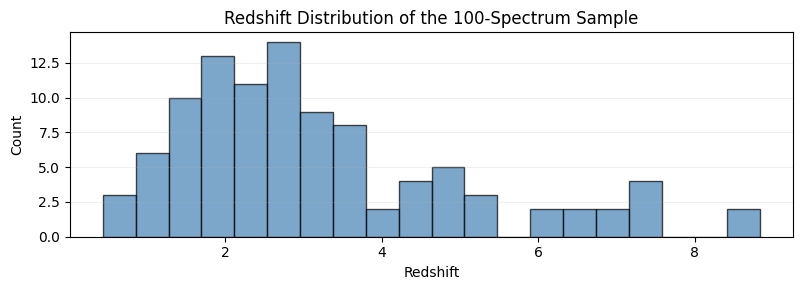

In [3]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(data['z'], bins=20, edgecolor='black', alpha=0.7, color='steelblue')
ax.set_xlabel('Redshift')
ax.set_ylabel('Count')
ax.set_title('Redshift Distribution of the 100-Spectrum Sample')
ax.grid(True, alpha=0.2, axis='y')
plt.tight_layout()
plt.show()

## 2. Load Model and Run Inference

We use `InferenceDataset` to handle the batch loading and per-spectrum normalization automatically.

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load model
zhead, norm_params = zestimatr.load_model(
    "../best_zhead_hires.pth",
    device=device,
    fallback_data_path="../data/spectra_dataset_2500_unaugmented.npz",
)

# Load dataset and run inference
dataset = InferenceDataset(data_path)
dataloader = DataLoader(dataset, batch_size=32, shuffle=False)
predictions = zestimatr.predict_redshifts(zhead, dataloader, norm_params, device)

print(f"\nPredictions for {len(predictions['z_pred'])} spectra")
print(f"Predicted z range: [{predictions['z_pred'].min():.3f}, {predictions['z_pred'].max():.3f}]")
print(f"Median uncertainty: {np.median(predictions['z_uncertainty']):.4f}")

Using device: cuda


Predicting: 100%|██████████| 4/4 [00:00<00:00, 14.64it/s]


Predictions for 100 spectra
Predicted z range: [1.198, 6.770]
Median uncertainty: 0.9484


## 3. Accuracy Metrics

In [5]:
z_pred = predictions['z_pred']
z_true = predictions['z_true']
z_unc = predictions['z_uncertainty']

metrics = zestimatr.compute_metrics(z_pred, z_true)

print("Accuracy Metrics (100 spectra):")
print(f"  MAE:               {metrics['mae']:.4f}")
print(f"  RMSE:              {metrics['rmse']:.4f}")
print(f"  NMAD:              {metrics['nmad']:.4f}")
print(f"  Median |dz|/(1+z): {metrics['median_rel_error']:.4f}")
print(f"  90th pctl |dz|/(1+z): {metrics['p90_rel_error']:.4f}")
print(f"  Outlier rate:      {metrics['outlier_rate']:.1%}  (|dz|/(1+z) > 0.15)")

Accuracy Metrics (100 spectra):
  MAE:               0.9291
  RMSE:              1.3837
  NMAD:              0.7690
  Median |dz|/(1+z): 0.1378
  90th pctl |dz|/(1+z): 0.6091
  Outlier rate:      48.0%  (|dz|/(1+z) > 0.15)


## 4. Calibration Metrics

Are the predicted uncertainties reliable? If the model is well-calibrated, ~68% of predictions should fall within 1 sigma of the true value.

In [6]:
cal = zestimatr.compute_calibration_metrics(z_pred, z_true, z_unc)

print("Calibration Metrics:")
print(f"  Calibration std:    {cal['calibration_std']:.3f}  (ideal = 1.0)")
print(f"  Calibration mean:   {cal['calibration_mean']:.3f}  (ideal = 0.0)")
print(f"  Median uncertainty: {cal['median_uncertainty']:.4f}")
print()
print("  Coverage fractions:")
print(f"    1-sigma: {cal['frac_1sigma']:.1%}  (ideal = 68.3%)")
print(f"    2-sigma: {cal['frac_2sigma']:.1%}  (ideal = 95.4%)")
print(f"    3-sigma: {cal['frac_3sigma']:.1%}  (ideal = 99.7%)")

Calibration Metrics:
  Calibration std:    1.218  (ideal = 1.0)
  Calibration mean:   0.143  (ideal = 0.0)
  Median uncertainty: 0.9484

  Coverage fractions:
    1-sigma: 66.0%  (ideal = 68.3%)
    2-sigma: 89.0%  (ideal = 95.4%)
    3-sigma: 97.0%  (ideal = 99.7%)


## 5. Visualizations

### Predicted vs True Redshift

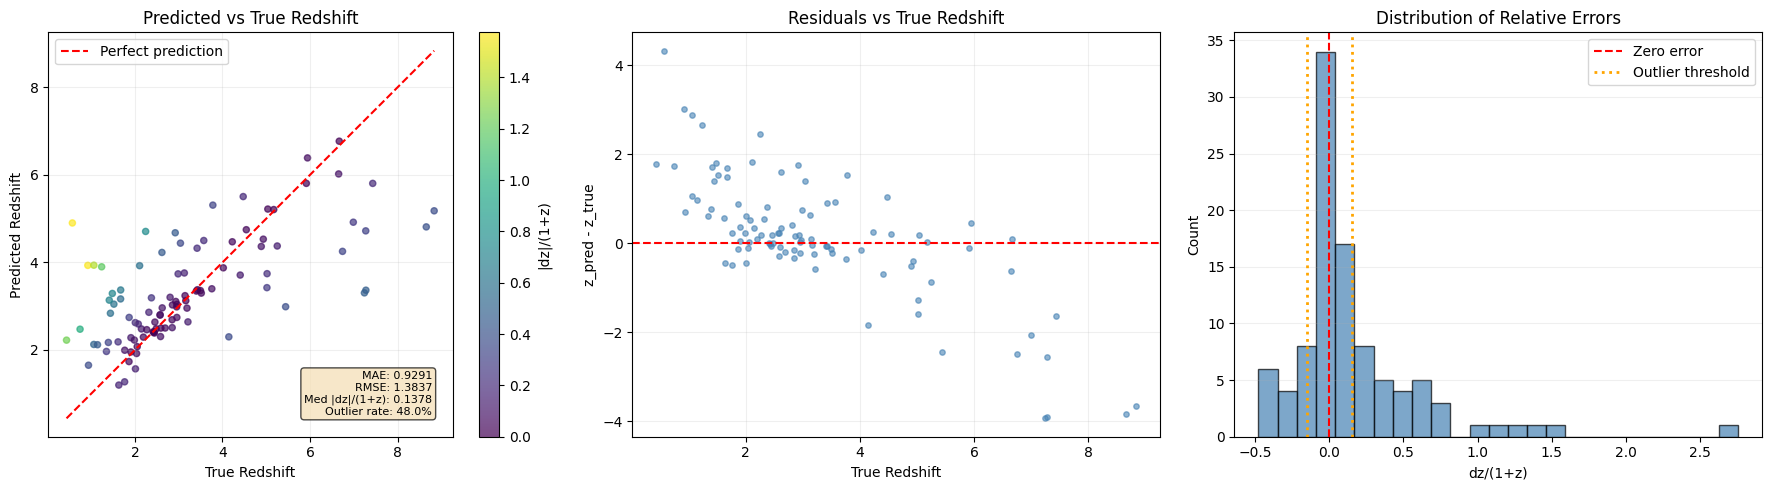

In [7]:
rel_err = np.abs(z_pred - z_true) / (1.0 + np.abs(z_true))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Predicted vs True, colored by relative error
ax = axes[0]
vmax = max(np.percentile(rel_err, 99), 1e-6)
sc = ax.scatter(z_true, z_pred, c=rel_err, s=20, alpha=0.7,
                vmin=0, vmax=vmax, cmap='viridis')
zmin = min(z_true.min(), z_pred.min())
zmax = max(z_true.max(), z_pred.max())
ax.plot([zmin, zmax], [zmin, zmax], 'r--', lw=1.5, label='Perfect prediction')
ax.set_xlabel('True Redshift')
ax.set_ylabel('Predicted Redshift')
ax.set_title('Predicted vs True Redshift')
ax.set_aspect('equal', adjustable='box')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.2)
cb = fig.colorbar(sc, ax=ax)
cb.set_label('|dz|/(1+z)')

metrics_text = (
    f"MAE: {metrics['mae']:.4f}\n"
    f"RMSE: {metrics['rmse']:.4f}\n"
    f"Med |dz|/(1+z): {metrics['median_rel_error']:.4f}\n"
    f"Outlier rate: {metrics['outlier_rate']:.1%}"
)
ax.text(0.95, 0.05, metrics_text, transform=ax.transAxes,
        ha='right', va='bottom',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7),
        fontsize=8)

# Panel 2: Residuals vs true redshift
ax = axes[1]
residuals = z_pred - z_true
ax.scatter(z_true, residuals, s=15, alpha=0.6, c='steelblue')
ax.axhline(0, color='red', linestyle='--', lw=1.5)
ax.set_xlabel('True Redshift')
ax.set_ylabel('z_pred - z_true')
ax.set_title('Residuals vs True Redshift')
ax.grid(True, alpha=0.2)

# Panel 3: Histogram of relative errors
ax = axes[2]
dz_1pz = (z_pred - z_true) / (1.0 + np.abs(z_true))
ax.hist(dz_1pz, bins=25, edgecolor='black', alpha=0.7, color='steelblue')
ax.axvline(0, color='red', linestyle='--', lw=1.5, label='Zero error')
ax.axvline(0.15, color='orange', linestyle=':', lw=2, label='Outlier threshold')
ax.axvline(-0.15, color='orange', linestyle=':', lw=2)
ax.set_xlabel('dz/(1+z)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Relative Errors')
ax.legend()
ax.grid(True, alpha=0.2, axis='y')

plt.tight_layout()
plt.show()

### Uncertainty Calibration

If the model's uncertainties are well-calibrated, the histogram of normalized residuals `(z_pred - z_true) / sigma` should follow a standard normal distribution N(0, 1).

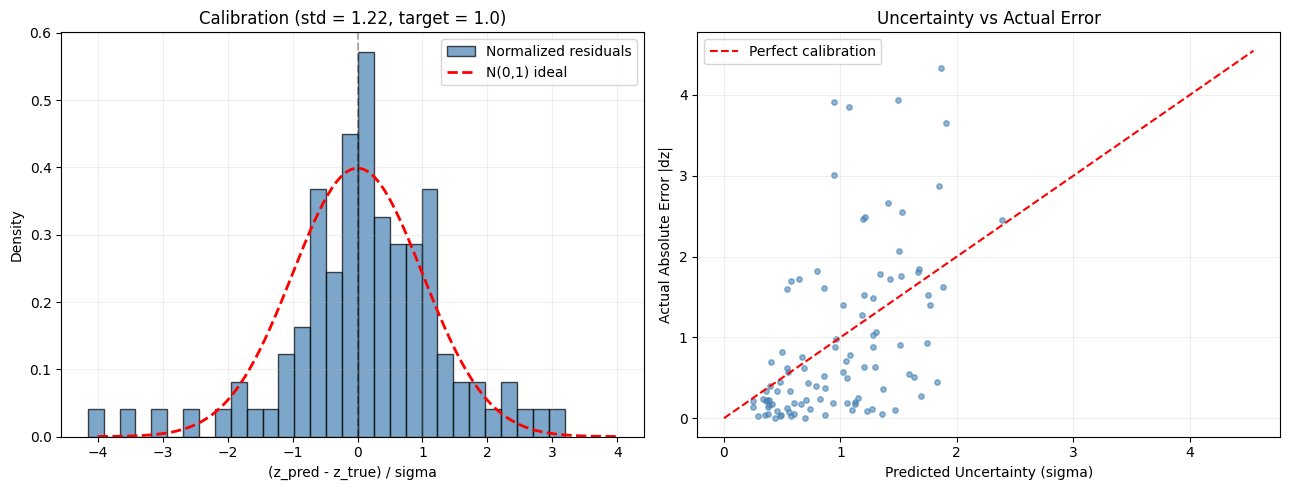

In [8]:
norm_res = (z_pred - z_true) / (z_unc + 1e-12)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Left: normalized residual histogram vs N(0,1)
ax1.hist(norm_res, bins=30, alpha=0.7, edgecolor='black', density=True,
         color='steelblue', label='Normalized residuals')
x_range = np.linspace(-4, 4, 200)
ax1.plot(x_range, 1/np.sqrt(2*np.pi) * np.exp(-0.5*x_range**2),
         'r--', lw=2, label='N(0,1) ideal')
ax1.axvline(0, color='k', linestyle='--', alpha=0.3)
ax1.set_xlabel('(z_pred - z_true) / sigma')
ax1.set_ylabel('Density')
ax1.set_title(f'Calibration (std = {cal["calibration_std"]:.2f}, target = 1.0)')
ax1.legend()
ax1.grid(True, alpha=0.2)

# Right: predicted uncertainty vs actual error
abs_err = np.abs(z_pred - z_true)
ax2.scatter(z_unc, abs_err, s=15, alpha=0.6, c='steelblue')
lim = max(z_unc.max(), abs_err.max()) * 1.05
ax2.plot([0, lim], [0, lim], 'r--', lw=1.5, label='Perfect calibration')
ax2.set_xlabel('Predicted Uncertainty (sigma)')
ax2.set_ylabel('Actual Absolute Error |dz|')
ax2.set_title('Uncertainty vs Actual Error')
ax2.legend()
ax2.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

### Per-Spectrum Results Table

A quick look at the first 10 predictions alongside ground truth.

In [9]:
print(f"{'ID':>6}  {'z_true':>8}  {'z_pred':>8}  {'sigma':>8}  {'|dz|/(1+z)':>10}  {'Outlier?':>8}")
print("-" * 62)
for i in range(min(10, len(z_pred))):
    gal_id = int(data['id'][i])
    zt = z_true[i]
    zp = z_pred[i]
    sig = z_unc[i]
    re = abs(zp - zt) / (1 + abs(zt))
    flag = "  ***" if re > 0.15 else ""
    print(f"{gal_id:>6}  {zt:>8.4f}  {zp:>8.4f}  {sig:>8.4f}  {re:>10.4f}{flag}")

    ID    z_true    z_pred     sigma  |dz|/(1+z)  Outlier?
--------------------------------------------------------------
   114    3.4203    4.3244    1.5148      0.2045  ***
   165    2.5767    2.8056    0.7016      0.0640
   183    1.9080    1.9535    0.8670      0.0156
   220    0.9390    1.6511    1.0468      0.3672  ***
   229    6.9900    4.9187    1.4994      0.2592  ***
   245    2.9546    2.9846    0.2909      0.0076
   256    1.4841    3.2908    1.6660      0.7273  ***
   284    5.9164    5.8061    0.7376      0.0159
   352    2.1484    2.4804    0.3590      0.1054
   375    1.7646    1.2718    1.0532      0.1782  ***


## 6. Built-in Plotting

`zestimatr` also provides `plot_predictions` for a quick two-panel summary plot.

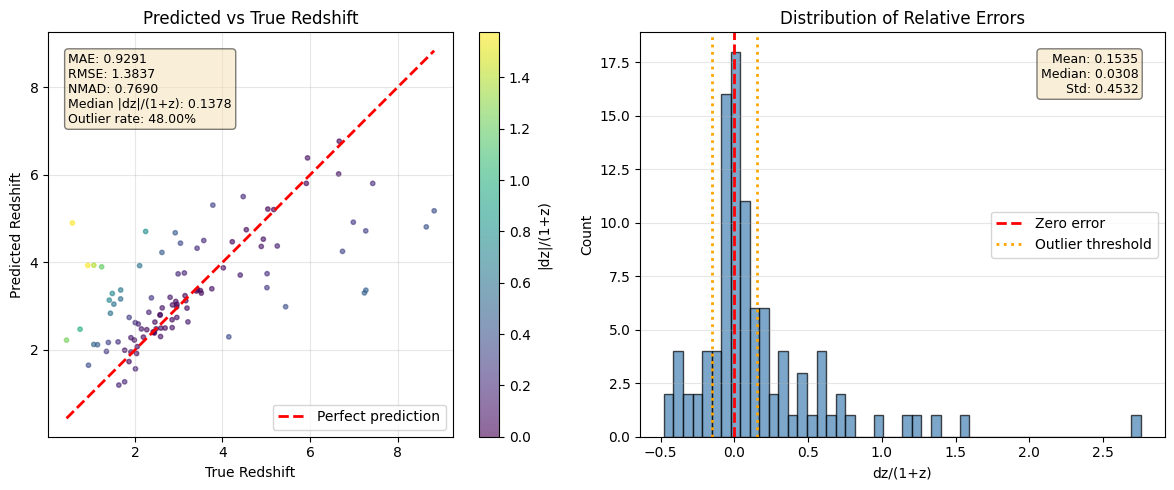

{'mae': 0.9291026571393013,
 'rmse': 1.3836551792801195,
 'median_abs_error': 0.5186911821365356,
 'nmad': 0.7690115466356277,
 'median_rel_error': 0.13777739876542838,
 'p90_rel_error': 0.6090511659797673,
 'outlier_rate': 0.48}

In [10]:
zestimatr.plot_predictions(predictions)

## Summary

We ran `zestimatr` on 100 spectra and evaluated:

- **Accuracy**: MAE, RMSE, NMAD, median relative error, outlier rate
- **Calibration**: whether predicted uncertainties match actual errors
- **Visualizations**: pred vs true scatter, residuals, error histograms, calibration diagnostics

These same tools scale to arbitrarily large datasets — just point `InferenceDataset` at your `.npz` file.